In [ ]:
# --- repo path setup (added during reorg) ---
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', 'src')))


In [1]:
import json
import numpy as np

with open("../data/spinodal2_saft.json", "r") as f:
    data = json.load(f)
spinodal2_m=np.array(data)

eps_as=np.linspace(0,10,21)
eps_cs=np.linspace(0,2.5,21)
eps_c_spinodal2_m=[]
eps_a_spinodal2_m=[]
for j in range(len(eps_cs)):
    if len(np.where(spinodal2_m[:,j])[0])>0 and eps_cs[j]<=2.3:
        eps_a_spinodal2_m.append(eps_as[np.min(np.where(spinodal2_m[:,j]==1)[0])])
        eps_c_spinodal2_m.append(eps_cs[j])


In [2]:
from scipy.interpolate import *

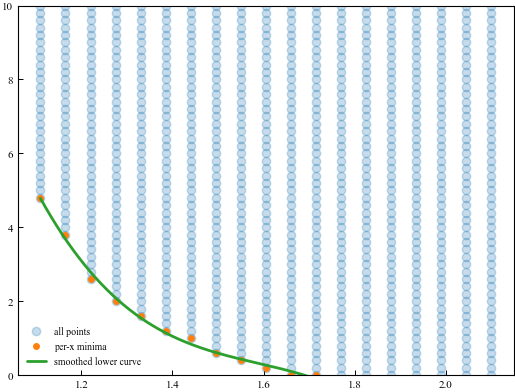

In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt

base_candidates = [
    "../data/spinodal_l_shaped_reduced_scan.npz",
]

npz_path = None
for p in base_candidates:
    if os.path.exists(p):
        npz_path = p
        break


if npz_path is None:
    raise FileNotFoundError("Could not find spinodal_simple_reduced_square_use4patch.npz")

data = np.load(npz_path)

points = data["points"] if "points" in data else np.empty((0, 2))
y = points[:, 0]
x = points[:, 1]
# =========================
# TUNABLES
# =========================
x_round_decimals = 6   # treat "each x" robustly if x is floaty; set 0 if x is exact
s_per_point = 0.5      # smoothing strength (bigger => smoother)
k = 3                  # spline degree (1=linear, 3=cubic)

# =========================
# 1) lower point for each x (min y at that x)
# =========================
xq = np.round(x, x_round_decimals)
ux = np.unique(xq)

xb = []
yb = []
for xv in ux:
    if xv>1.75:
        continue
    m = (xq == xv)
    yi = y[m].min()
    xb.append(float(xv))
    yb.append(float(yi))

#xb.extend(list(np.linspace(0.47,0.48,11)))
#yb.extend(list(np.linspace(8,11,11)))

xb = np.array(xb)
yb = np.array(yb)

# sort by x for spline
ordx = np.argsort(xb)
xb, yb = xb[ordx], yb[ordx]

# =========================
# 2) smooth curve through those points
# =========================
spl = UnivariateSpline(xb, yb, k=k, s=s_per_point * len(xb), ext=3)
xgrid = np.linspace(xb.min(), xb.max(), 800)
ygrid = spl(xgrid)

# =========================
# plot
# =========================
plt.figure()
plt.plot(x, y, "o", alpha=0.25, label="all points")
plt.plot(xb, yb, "o", markersize=4, label="per-x minima")
plt.plot(xgrid, ygrid, "-", linewidth=2, label="smoothed lower curve")
plt.legend()
plt.ylim([0,10])
plt.show()


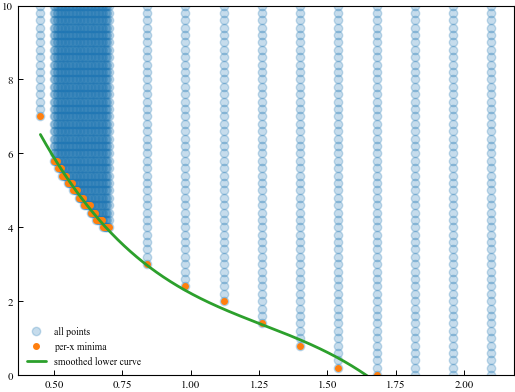

In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt

base_candidates = [
    "../data/spinodal_stick_shaped_reduced_scan.npz",
]

npz_path = None
for p in base_candidates:
    if os.path.exists(p):
        npz_path = p
        break


if npz_path is None:
    raise FileNotFoundError("Could not find spinodal_simple_reduced_square_use4patch.npz")

data = np.load(npz_path)

points = data["points"] if "points" in data else np.empty((0, 2))
y = points[:, 0]
x = points[:, 1]
# =========================
# TUNABLES
# =========================
x_round_decimals = 6   # treat "each x" robustly if x is floaty; set 0 if x is exact
s_per_point = 0.5      # smoothing strength (bigger => smoother)
k = 3                  # spline degree (1=linear, 3=cubic)

# =========================
# 1) lower point for each x (min y at that x)
# =========================
xq = np.round(x, x_round_decimals)
ux = np.unique(xq)

xb = []
yb = []
for xv in ux:
    if xv>1.75:
        continue
    m = (xq == xv)
    yi = y[m].min()
    xb.append(float(xv))
    yb.append(float(yi))

#xb.extend(list(np.linspace(0.47,0.48,11)))
#yb.extend(list(np.linspace(8,11,11)))

xb = np.array(xb)
yb = np.array(yb)

# sort by x for spline
ordx = np.argsort(xb)
xb, yb = xb[ordx], yb[ordx]

# =========================
# 2) smooth curve through those points
# =========================
spl = UnivariateSpline(xb, yb, k=k, s=s_per_point * len(xb), ext=3)
xgrid_s = np.linspace(xb.min(), xb.max(), 800)
ygrid_s = spl(xgrid_s)

# =========================
# plot
# =========================
plt.figure()
plt.plot(x, y, "o", alpha=0.25, label="all points")
plt.plot(xb, yb, "o", markersize=4, label="per-x minima")
plt.plot(xgrid_s, ygrid_s, "-", linewidth=2, label="smoothed lower curve")
plt.legend()
plt.ylim([0,10])
plt.show()


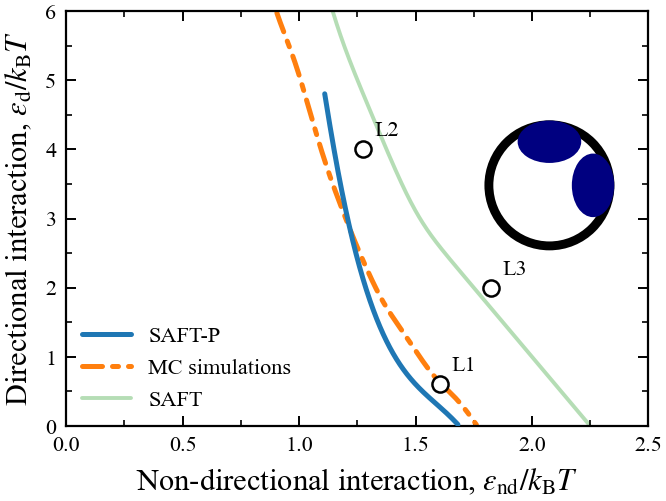

In [12]:
import re
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from scipy.ndimage import gaussian_filter1d

# -------------------- PRL/APS-ish style --------------------
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "STIXGeneral", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 8,
    "axes.labelsize": 9,
    "legend.fontsize": 7,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.8,
    "lines.solid_capstyle": "round",
    "lines.dash_capstyle": "round",
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 3.5,
    "ytick.major.size": 3.5,
    "xtick.minor.size": 2.0,
    "ytick.minor.size": 2.0,
    "xtick.major.width": 0.7,
    "ytick.major.width": 0.7,
    "xtick.minor.width": 0.6,
    "ytick.minor.width": 0.6,
    "legend.frameon": False,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# -------------------- parsing --------------------
pattern = re.compile(r'^\s*(?:θ\*|theta\*)\s*:\s*\(([^)]*)\)')
def first_two_from_line(s: str):
    m = pattern.match(s)
    if not m:
        return None
    inside = m.group(1)
    parts = [p.strip() for p in inside.split(',')]
    if len(parts) >= 2:
        try:
            return float(parts[0]), float(parts[1])
        except ValueError:
            return None

f = open('../results_logs/all_trace_coexist_l.out','r')
lines = f.readlines()
f.close()

xs, ys = [], []
for line in lines:
    if line.startswith('θ'):
        out = first_two_from_line(line)
        if out is None:
            continue
        x, y = out
        if (x < 0.56) or (x < 0) or np.isnan(x):
            continue
        xs.append(x); ys.append(y)

# keep your manual cap points
#xs += [0.9, 0.9,0.89]
#ys += [7.0, 10,11]

# -------------------- smoothing (same as yours; key change: NO xlim forcing) --------------------
def _fit_slope(x, y, k=10, side="left"):
    k = min(int(k), len(x))
    if k < 2:
        return 0.0
    if side == "left":
        xx, yy = x[:k], y[:k]
    else:
        xx, yy = x[-k:], y[-k:]
    A = np.vstack([xx, np.ones_like(xx)]).T
    m, b = np.linalg.lstsq(A, yy, rcond=None)[0]
    return float(m)

def gaussian_smooth_xy_no_edge_curvature(x, y, *, sigma=4.0, n=800, xlim=None, pad_mult=4, kfit=10):
    x = np.asarray(x, float); y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    idx = np.argsort(x)
    x, y = x[idx], y[idx]

    if xlim is None:
        x0, x1 = float(x.min()), float(x.max())
    else:
        x0, x1 = map(float, xlim)
        keep = (x >= x0) & (x <= x1)
        x, y = x[keep], y[keep]

    xg = np.linspace(x0, x1, int(n))
    yg = np.interp(xg, x, y)

    pad = int(max(8, pad_mult * sigma))
    mL = _fit_slope(xg, yg, k=kfit, side="left")
    mR = _fit_slope(xg, yg, k=kfit, side="right")

    dx = xg[1] - xg[0]
    left_x  = xg[0]  - dx * np.arange(pad, 0, -1)
    right_x = xg[-1] + dx * np.arange(1, pad + 1)
    left_y  = yg[0]  + mL * (left_x  - xg[0])
    right_y = yg[-1] + mR * (right_x - xg[-1])

    yg_pad = np.concatenate([left_y, yg, right_y])
    ygs_pad = gaussian_filter1d(yg_pad, sigma=float(sigma), mode="nearest")
    ygs = ygs_pad[pad:-pad]
    return xg, ygs

def trim_at_floor(x, y, floor=0.0, eps=2e-2):
    x = np.asarray(x); y = np.asarray(y)
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    idx = np.where(y <= (floor + eps))[0]
    if idx.size == 0:
        return x, y
    k = int(idx[0])
    return x[:k+1], y[:k+1]

# ---- apply to your curves (assumes xgrid,ygrid, eps_c_spinodal2_m,eps_a_spinodal2_m exist) ----
x1 = np.array(xgrid, float); y1 = np.array(ygrid, float)           # SAFT-P
x2 = np.array(xs, float);    y2 = np.array(ys, float)              # MC
x3 = np.array(eps_c_spinodal2_m, float)
y3 = np.array(eps_a_spinodal2_m, float)                            # SAFT

# keep your heavy smoothing if you want; this just fixes the end artifact
x1g, y1gs = gaussian_smooth_xy_no_edge_curvature(x1, y1, sigma=50.0, n=900)
x2g, y2gs = gaussian_smooth_xy_no_edge_curvature(x2, y2, sigma=50.0, n=900)
x3g, y3gs = gaussian_smooth_xy_no_edge_curvature(x3, y3, sigma=50.0, n=900)

# stop drawing when they hit ~0 -> removes vertical end segment
x1g, y1gs = trim_at_floor(x1g, y1gs, floor=0.0, eps=0.02)
x2g, y2gs = trim_at_floor(x2g, y2gs, floor=0.0, eps=0.02)
x3g, y3gs = trim_at_floor(x3g, y3gs, floor=0.0, eps=0.02)

# -------------------- plot --------------------
fig = plt.figure(figsize=(3.375, 2.55), dpi=200, constrained_layout=True)
ax = fig.add_subplot(111)

ax.plot(x1g, y1gs, label=r"SAFT-P", zorder=3)
ax.plot(x2g, y2gs, linestyle=(0, (4, 2, 1.2, 2)), label=r"MC simulations", zorder=2)
ax.plot(x3g, y3gs, linewidth=1.4, alpha=0.35, label=r"SAFT", zorder=1)
#ax.plot(xb,yb,'o',markersize=2)

# Manual benchmark points
MANUAL_POINT_REQUESTS = [
    {"system": "stick", "name": "1", "eps_a": 2.0, "eps_c": 1.176},
    {"system": "stick", "name": "2", "eps_a": 3.8, "eps_c": 0.84},
    {"system": "stick", "name": "3", "eps_a": 6.0, "eps_c": 1.008},
    {"system": "l",     "name": "1", "eps_a": 0.60, "eps_c": 1.605},
    {"system": "l",     "name": "2", "eps_a": 4.0, "eps_c": 1.275},
    {"system": "l",     "name": "3", "eps_a": 2.0, "eps_c": 1.825},
]

panel_letters = ["A", "B", "C", "L1", "L2", "L3"]

for i, pt in enumerate(MANUAL_POINT_REQUESTS):
    x = pt["eps_c"]
    y = pt["eps_a"]

    if pt["system"] == "l":
        ax.plot(
            x, y,
            marker="o",
            markersize=5.8,
            markerfacecolor="white",
            markeredgecolor="black",
            markeredgewidth=0.9,
            linestyle="None",
            zorder=5,
        )
        ax.text(
            x + 0.05, y + 0.12, panel_letters[i],
            fontsize=8, ha="left", va="bottom", zorder=6
        )

ax.set_xlim(0.0, 2.5)
ax.set_ylim(0.0, 6)

ax.set_xlabel(r"Non-directional interaction, $\epsilon_{\mathrm{nd}}/k_{\mathrm{B}}T$",fontsize=11)
ax.set_ylabel(r"Directional interaction, $\varepsilon_{\mathrm{d}}/k_{\mathrm{B}}T$",fontsize=11)

ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(which="both", top=True, right=True)

ax.legend(loc="lower left", handlelength=2.2, borderaxespad=0.3,fontsize=8)
from matplotlib.patches import Circle, Ellipse

# ----------------------------- inset schematic: sphere + 2 ellipse patches -----------------------------
ax_in = ax.inset_axes([0.70, 0.08, 0.26, 1])  # [left,bottom,width,height] in axes fraction
ax_in.set_axis_off()
ax_in.set_facecolor("none")
for sp in ax_in.spines.values():
    sp.set_visible(False)

ax_in.set_aspect("equal", adjustable="box")
ax_in.set_xlim(-1.25, 1.25)
ax_in.set_ylim(-1.25, 1.25)

# Sphere outline (thick, like your example)
R = 1.0
ax_in.add_patch(Circle((0.0, 0.0), R, fill=False, linewidth=3.2))

# Elliptical patches (one side, one bottom)
# Right-side patch (vertical ellipse near boundary)
ax_in.add_patch(Ellipse(
    (0.72, 0.0),   # center
    0.70, 1.05,     # width, height
    angle=0.0,
    linewidth=0.0,
    fill=True,
    color="navy"    # set explicitly to match the example
))

# Bottom patch (horizontal ellipse near boundary)
ax_in.add_patch(Ellipse(
    (-0, 0.72), # center
    1.05, 0.7,     # width, height
    angle=0.0,
    linewidth=0.0,
    fill=True,
    color="navy"
))
# no grid for PRL; if you insist, uncomment:
# ax.grid(True, which="major", linewidth=0.4, alpha=0.25)

fig.savefig("../figures/phases_diagram_l_saftp_simulations.pdf")
fig.savefig("../figures/phases_diagram_l_saftp_simulations.png", dpi=600)
plt.show()


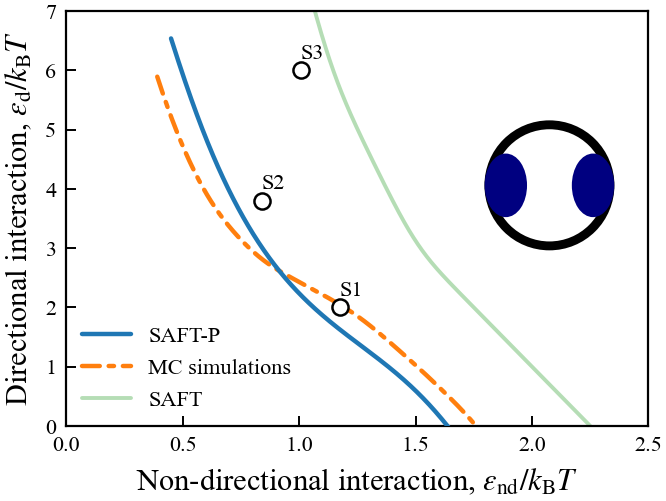

In [13]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from scipy.ndimage import gaussian_filter1d
import re

# ----------------------------- PRL/APS-like styling -----------------------------
mpl.rcParams.update({
    # Fonts: vector-friendly, APS-ish
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "STIXGeneral", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 8,                 # PRL single-column default feel
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "legend.fontsize": 7,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,

    # Lines/axes
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.6,
    "lines.solid_capstyle": "round",
    "lines.dash_capstyle": "round",

    # Ticks
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 3.5,
    "ytick.major.size": 3.5,
    "xtick.minor.size": 2.0,
    "ytick.minor.size": 2.0,
    "xtick.major.width": 0.7,
    "ytick.major.width": 0.7,
    "xtick.minor.width": 0.6,
    "ytick.minor.width": 0.6,

    # Legend
    "legend.frameon": False,

    # Save
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
    "pdf.fonttype": 42,   # embed TrueType fonts
    "ps.fonttype": 42,
})

# ----------------------------- parsing (your code) -----------------------------
pattern = re.compile(r'^\s*(?:θ\*|theta\*)\s*:\s*\(([^)]*)\)')
def first_two_from_line(s: str):
    m = pattern.match(s)
    if not m:
        return None
    inside = m.group(1)
    parts = [p.strip() for p in inside.split(',')]
    if len(parts) >= 2:
        try:
            return float(parts[0]), float(parts[1])
        except ValueError:
            return None

f = open('../results_logs/all_trace_coexist_stick.out','r')
lines = f.readlines()
f.close()

xs, ys = [], []
for line in lines:
    if line.startswith('θ'):
        out = first_two_from_line(line)
        if out is None:
            continue
        x, y = out
        if (x < 0) or np.isnan(x):
            continue
        xs.append(x); ys.append(y)
#xs.extend([0.39]*20)
#ys.extend(list(np.linspace(7,11,20)))
# ----------------------------- smoothing (your code, tightened) -----------------------------
def _fit_slope(x, y, k=10, side="left"):
    k = min(int(k), len(x))
    if k < 2:
        return 0.0
    if side == "left":
        xx, yy = x[:k], y[:k]
    else:
        xx, yy = x[-k:], y[-k:]
    A = np.vstack([xx, np.ones_like(xx)]).T
    m, b = np.linalg.lstsq(A, yy, rcond=None)[0]
    return float(m)

def gaussian_smooth_xy_no_edge_curvature(x, y, *, sigma=10.0, n=800, xlim=None, pad_mult=4, kfit=12):
    x = np.asarray(x, float); y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    idx = np.argsort(x)
    x, y = x[idx], y[idx]

    if xlim is None:
        x0, x1 = float(x.min()), float(x.max())
    else:
        x0, x1 = map(float, xlim)
        keep = (x >= x0) & (x <= x1)
        x, y = x[keep], y[keep]

    xg = np.linspace(x0, x1, int(n))
    yg = np.interp(xg, x, y)

    pad = int(max(8, pad_mult * sigma))
    mL = _fit_slope(xg, yg, k=kfit, side="left")
    mR = _fit_slope(xg, yg, k=kfit, side="right")
    dx = xg[1] - xg[0]

    left_x  = xg[0]  - dx * np.arange(pad, 0, -1)
    right_x = xg[-1] + dx * np.arange(1, pad + 1)
    left_y  = yg[0]  + mL * (left_x  - xg[0])
    right_y = yg[-1] + mR * (right_x - xg[-1])

    yg_pad = np.concatenate([left_y, yg, right_y])
    ygs_pad = gaussian_filter1d(yg_pad, sigma=float(sigma), mode="nearest")
    ygs = ygs_pad[pad:-pad]
    return xg, ygs

# ---- your arrays (must exist): xgrid_s,ygrid_s,xgrid,ygrid, eps_c_spinodal2_m, eps_a_spinodal2_m ----
x1 = np.array(xgrid_s, float); y1 = np.array(ygrid_s, float)     # SAFT-P
x2 = np.array(xs, float);      y2 = np.array(ys, float)          # MC
x3 = np.array(eps_c_spinodal2_m, float); y3 = np.array(eps_a_spinodal2_m, float)  # SAFT baseline

# DO NOT use sigma=50 unless your curve is extremely noisy; it visibly distorts PRL-quality curves.
x1g, y1gs = gaussian_smooth_xy_no_edge_curvature(x1, y1, sigma=50.0, n=800, xlim=None)
x2g, y2gs = gaussian_smooth_xy_no_edge_curvature(x2, y2, sigma=50.0, n=800, xlim=None)
x3g, y3gs = gaussian_smooth_xy_no_edge_curvature(x3, y3, sigma=50.0, n=800, xlim=None)

# ----------------------------- plotting (PRL publishable) -----------------------------
# Single-column PRL width ~3.375 in. Use height ~2.4–2.6 in for this aspect.
fig = plt.figure(figsize=(3.375, 2.55), dpi=200, constrained_layout=True)
ax = fig.add_subplot(111)

# Curves
ax.plot(x1g, y1gs, label=r"SAFT-P", zorder=3)
ax.plot(x2g, y2gs, linestyle=(0, (4, 2, 1.2, 2)), label=r"MC simulations", zorder=2)
ax.plot(x3g, y3gs, linewidth=1.4, alpha=0.35, label=r"SAFT", zorder=1)

ax.set_xlabel(r"Non-directional interaction, $\epsilon_{\mathrm{nd}}/k_{\mathrm{B}}T$",fontsize=11)
ax.set_ylabel(r"Directional interaction, $\varepsilon_{\mathrm{d}}/k_{\mathrm{B}}T$",fontsize=11)
# Manual benchmark points
MANUAL_POINT_REQUESTS = [
    {"system": "stick", "name": "1", "eps_a": 2.0, "eps_c": 1.176},
    {"system": "stick", "name": "2", "eps_a": 3.8, "eps_c": 0.84},
    {"system": "stick", "name": "3", "eps_a": 6.0, "eps_c": 1.008},
    {"system": "l",     "name": "1", "eps_a": 0.60, "eps_c": 1.605},
    {"system": "l",     "name": "2", "eps_a": 4.0, "eps_c": 1.275},
    {"system": "l",     "name": "3", "eps_a": 2.0, "eps_c": 1.825},
]

panel_letters = ["S1", "S2", "S3", "D", "E", "F"]

for i, pt in enumerate(MANUAL_POINT_REQUESTS):
    x = pt["eps_c"]
    y = pt["eps_a"]

    if pt["system"] == "stick":
        ax.plot(
            x, y,
            marker="o",
            markersize=5.8,
            markerfacecolor="white",
            markeredgecolor="black",
            markeredgewidth=0.9,
            linestyle="None",
            zorder=5,
        )
        ax.text(
            x + 0, y + 0.12, panel_letters[i],
            fontsize=8, ha="left", va="bottom", zorder=6
        )

# Legend: compact, non-boxed, no overlap with data
ax.legend(loc="lower left", handlelength=2.2, borderaxespad=0.3,fontsize=8)
from matplotlib.patches import Circle, Ellipse

# ----------------------------- inset schematic: sphere + 2 ellipse patches -----------------------------
ax_in = ax.inset_axes([0.70, 0.08, 0.26, 1])  # [left,bottom,width,height] in axes fraction
ax_in.set_axis_off()
ax_in.set_facecolor("none")
for sp in ax_in.spines.values():
    sp.set_visible(False)

ax_in.set_aspect("equal", adjustable="box")
ax_in.set_xlim(-1.25, 1.25)
ax_in.set_ylim(-1.25, 1.25)

# Sphere outline (thick, like your example)
R = 1.0
ax_in.add_patch(Circle((0.0, 0.0), R, fill=False, linewidth=3.2))

# Elliptical patches (one side, one bottom)
# Right-side patch (vertical ellipse near boundary)
ax_in.add_patch(Ellipse(
    (0.72, 0.0),   # center
    0.70, 1.05,     # width, height
    angle=0.0,
    linewidth=0.0,
    fill=True,
    color="navy"    # set explicitly to match the example
))

# Bottom patch (horizontal ellipse near boundary)
ax_in.add_patch(Ellipse(
    (-0.72, 0.0), # center
    0.70, 1.05,     # width, height
    angle=0.0,
    linewidth=0.0,
    fill=True,
    color="navy"
))

ax.set_xlim([0,2.5])
ax.set_ylim([0,7])
# No grid for PRL (keep it clean). If you insist, use:
# ax.grid(True, which="major", linewidth=0.4, alpha=0.25)

# Export: vector PDF for PRL + high-dpi PNG for quick viewing
fig.savefig("../figures/phase_diagram_prl_stick.pdf")                 # submit this
fig.savefig("../figures/phase_diagram_prl_stick.png", dpi=600)        # preview/slide
plt.show()
